# Refactor Agent v2 — CodeT5+ 770M Fine-tuning on RCCT Java
### Autonomous Multi-Agent Platform — Clean Retraining

**All v1 bugs fixed:**
- `Seq2SeqTrainer` with `predict_with_generate=True` (was plain `Trainer`)
- Input=512 tokens, Output=256 tokens (was both 256)
- Dynamic padding via `DataCollatorForSeq2Seq` (was `max_length` padding)
- `fp16=True` (was `False`)
- `load_best_model_at_end=True` with early stopping
- Fresh training — no Colab→Kaggle checkpoint transfer
- **New:** CodeBLEU + Exact Match + AST Validity + Complexity metrics

| Step | Description | Time (P100) |
|------|-------------|------------|
| 1 | Setup + imports | 3 min |
| 2 | Load dataset + check size | 2 min |
| 3 | EDA | 2 min |
| 4 | Quality filtering + tokenisation | 5 min |
| 5 | Load model + LoRA | 1 min |
| 6 | Train 5 epochs (early stopping) | ~4-6 hrs |
| 7 | Evaluation — 8 metrics | 15 min |
| 8 | Visualisations (saved as PNG) | 5 min |
| 9 | Save all results + zip | 5 min |

## Step 1 — Setup

In [1]:
import os, re, gc, json, warnings, logging, shutil, math
import subprocess, sys

os.environ["CUDA_VISIBLE_DEVICES"]    = "0"
os.environ["TOKENIZERS_PARALLELISM"]  = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

pip(
    "transformers==4.44.0",
    "peft==0.10.0",
    "accelerate==0.29.0",
    "datasets>=2.19.0",
    "evaluate", "rouge_score", "sacrebleu",
    "codebleu",
    "sentencepiece", "huggingface_hub>=0.22.0",
    "seaborn>=0.13.0", "plotly>=5.20.0",
    "javalang",
)
print("All packages installed")

All packages installed


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from tqdm.auto import tqdm
from datetime import datetime

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq, EarlyStoppingCallback, set_seed,
)
from peft import LoraConfig, TaskType, get_peft_model
import evaluate as hf_evaluate

try:
    import javalang
    HAS_JAVALANG = True
except ImportError:
    HAS_JAVALANG = False
    print("javalang not available — AST checks will use brace balance")

try:
    from codebleu import calc_codebleu
    HAS_CODEBLEU = True
except ImportError:
    HAS_CODEBLEU = False
    print("codebleu not available — will skip CodeBLEU metric")

set_seed(42)

plt.rcParams.update({
    "figure.facecolor":"#0d1117","axes.facecolor":"#161b22",
    "axes.edgecolor":"#30363d","axes.labelcolor":"#c9d1d9",
    "text.color":"#c9d1d9","xtick.color":"#8b949e",
    "ytick.color":"#8b949e","grid.color":"#21262d",
    "grid.alpha":0.6,"font.family":"monospace","figure.dpi":110,
})
PALETTE = ["#58a6ff","#3fb950","#f78166","#d2a8ff","#ffa657",
           "#79c0ff","#56d364","#ff7b72","#bc8cff","#ffb77a"]

# ── Constants ─────────────────────────────────────────────────────────────
MODEL_NAME     = "Salesforce/codet5p-770m"
MAX_INPUT_LEN  = 512   # smelly code — fixed by CodeT5+ architecture
MAX_TARGET_LEN = 256   # refactored code
OUTPUT_DIR     = "/kaggle/working/refactor_agent_final"
LOG_DIR        = "/kaggle/working/logs"
GRAPHS_DIR     = "/kaggle/working/graphs"
RESULTS_DIR    = "/kaggle/working/results"
DATASET_DIR    = "/kaggle/input/datasets/ishashah2493/rcct-dataset"

# ── Hyperparameters (well-established for CodeT5+ LoRA, no HPO needed) ───
LR         = 2e-4    # conservative — avoids overfitting
LORA_R     = 16      # higher rank — refactoring needs more capacity than doc
LORA_ALPHA = 32      # standard 2x ratio
LORA_DROP  = 0.05
BATCH      = 2   # reduced for T4 VRAM
GRAD_ACC   = 16      # increased to keep eff_batch=32
EPOCHS     = 3   # 3 epochs fits in 5-6 hrs on T4

for d in [OUTPUT_DIR, LOG_DIR, GRAPHS_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"\nTraining config:")
print(f"  LR={LR:.0e} | LoRA r={LORA_R} | alpha={LORA_ALPHA}")
print(f"  Batch={BATCH} | GradAcc={GRAD_ACC} | EffBatch={BATCH*GRAD_ACC}")
print(f"  Input={MAX_INPUT_LEN} | Output={MAX_TARGET_LEN} | Epochs={EPOCHS}")
print(f"\nToken limit note:")
print(f"  CodeT5+ 770M has a FIXED 512-token window (architecture constraint).")
print(f"  Methods >45 lines will be truncated. This is a known limitation.")
print(f"  To increase: switch to codet5p-2b (2048 tokens) — future work.")

2026-03-21 10:32:48.917990: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774089168.942536   38215 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774089168.950333   38215 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774089168.971829   38215 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774089168.971861   38215 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774089168.971864   38215 computation_placer.cc:177] computation placer alr

PyTorch  : 2.10.0+cu128
Device   : cuda
GPU      : Tesla T4
VRAM     : 15.6 GB

Training config:
  LR=2e-04 | LoRA r=16 | alpha=32
  Batch=2 | GradAcc=16 | EffBatch=32
  Input=512 | Output=256 | Epochs=3

Token limit note:
  CodeT5+ 770M has a FIXED 512-token window (architecture constraint).
  Methods >45 lines will be truncated. This is a known limitation.
  To increase: switch to codet5p-2b (2048 tokens) — future work.


In [3]:
import os, glob

print("Scanning /kaggle/input/ ...")
for root, dirs, files in os.walk("/kaggle/input/"):
    for fname in files:
        full = os.path.join(root, fname)
        size = os.path.getsize(full) / 1e6
        print(f"  {full}  ({size:.1f} MB)")

Scanning /kaggle/input/ ...
  /kaggle/input/datasets/ishashah2493/rcct-dataset/rcct_val.json  (1.2 MB)
  /kaggle/input/datasets/ishashah2493/rcct-dataset/rcct_train.json  (9.7 MB)
  /kaggle/input/datasets/ishashah2493/rcct-dataset/rcct_test.json  (1.2 MB)


## Step 2 — Load Dataset + Check Size

In [4]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)
DATASET_DIR = "/kaggle/input/datasets/ishashah2493/rcct-dataset"
# Load available splits
train_data = load_json(f"{DATASET_DIR}/rcct_train.json")
val_data   = load_json(f"{DATASET_DIR}/rcct_val.json")

# Check for test split
test_path = f"{DATASET_DIR}/rcct_test.json"
if os.path.exists(test_path):
    test_data = load_json(test_path)
    print("Test split found")
else:
    # Split val 50/50 into val and test
    mid = len(val_data) // 2
    test_data = val_data[mid:]
    val_data  = val_data[:mid]
    print("No test file — split val into val+test")

print(f"\nDataset sizes:")
print(f"  Train : {len(train_data):,} examples")
print(f"  Val   : {len(val_data):,} examples")
print(f"  Test  : {len(test_data):,} examples")
print(f"  Total : {len(train_data)+len(val_data)+len(test_data):,} examples")

# Show available keys
print(f"\nFields in each example: {list(train_data[0].keys())}")

# Sample
print(f"\nSample input  (first 200 chars):")
print(train_data[0]["input"][:200])
print(f"\nSample output (first 200 chars):")
print(train_data[0]["output"][:200])

# IMPORTANT: decide training strategy based on dataset size
n = len(train_data)
if n < 1000:
    print(f"\nWARNING: Only {n} training examples.")
    print("Risk of overfitting. Reduce epochs to 3, consider data augmentation.")
elif n < 5000:
    print(f"\nSmall dataset ({n} examples). Use all examples. Epochs=5 with early stopping.")
else:
    print(f"\nGood dataset size ({n:,} examples). Proceed with configured settings.")

Test split found

Dataset sizes:
  Train : 13,756 examples
  Val   : 1,719 examples
  Test  : 1,719 examples
  Total : 17,194 examples

Fields in each example: ['input', 'output']

Sample input  (first 200 chars):
protected static String commentFormat(String comment) {
		if (comment == null || comment.isEmpty()) return "";
		// truncate comment to 255 Bytes - a tinyblob
		while (comment.getBytes(ENCODING).lengt

Sample output (first 200 chars):
protected static String commentFormat(String comment) {
		if (comment == null || comment.length() == 0) return "";
		// truncate comment to 255 Bytes - a tinyblob
		while (comment.getBytes(ENCODING).l

Good dataset size (13,756 examples). Proceed with configured settings.


## Step 3 — EDA

In [5]:
train_df = pd.DataFrame(train_data)
train_df["input_words"]  = train_df["input"].str.split().str.len()
train_df["output_words"] = train_df["output"].str.split().str.len()
train_df["input_lines"]  = train_df["input"].str.count("\n") + 1
train_df["output_lines"] = train_df["output"].str.count("\n") + 1

print("TRAINING SET STATS:")
print(train_df[["input_words","output_words","input_lines","output_lines"]]
      .describe().round(1).to_string())

fits_512 = (train_df["input_words"] <= 512).mean() * 100
fits_256 = (train_df["output_words"] <= 256).mean() * 100
print(f"\nCoverage:")
print(f"  Input fits 512 tokens  : {fits_512:.1f}%")
print(f"  Output fits 256 tokens : {fits_256:.1f}%")
if fits_512 < 80:
    print(f"  WARNING: {100-fits_512:.0f}% of training examples will be truncated.")
    print(f"  Consider using codet5p-2b (2048 tokens) for better coverage.")

TRAINING SET STATS:
       input_words  output_words  input_lines  output_lines
count      13756.0       13756.0      13756.0       13756.0
mean          26.9          24.3          8.7           7.8
std           15.7          15.4          4.5           4.4
min            3.0           3.0          1.0           1.0
25%           15.0          13.0          5.0           4.0
50%           24.0          21.0          8.0           7.0
75%           35.0          32.0         11.0          10.0
max          189.0         189.0         42.0          41.0

Coverage:
  Input fits 512 tokens  : 100.0%
  Output fits 256 tokens : 100.0%


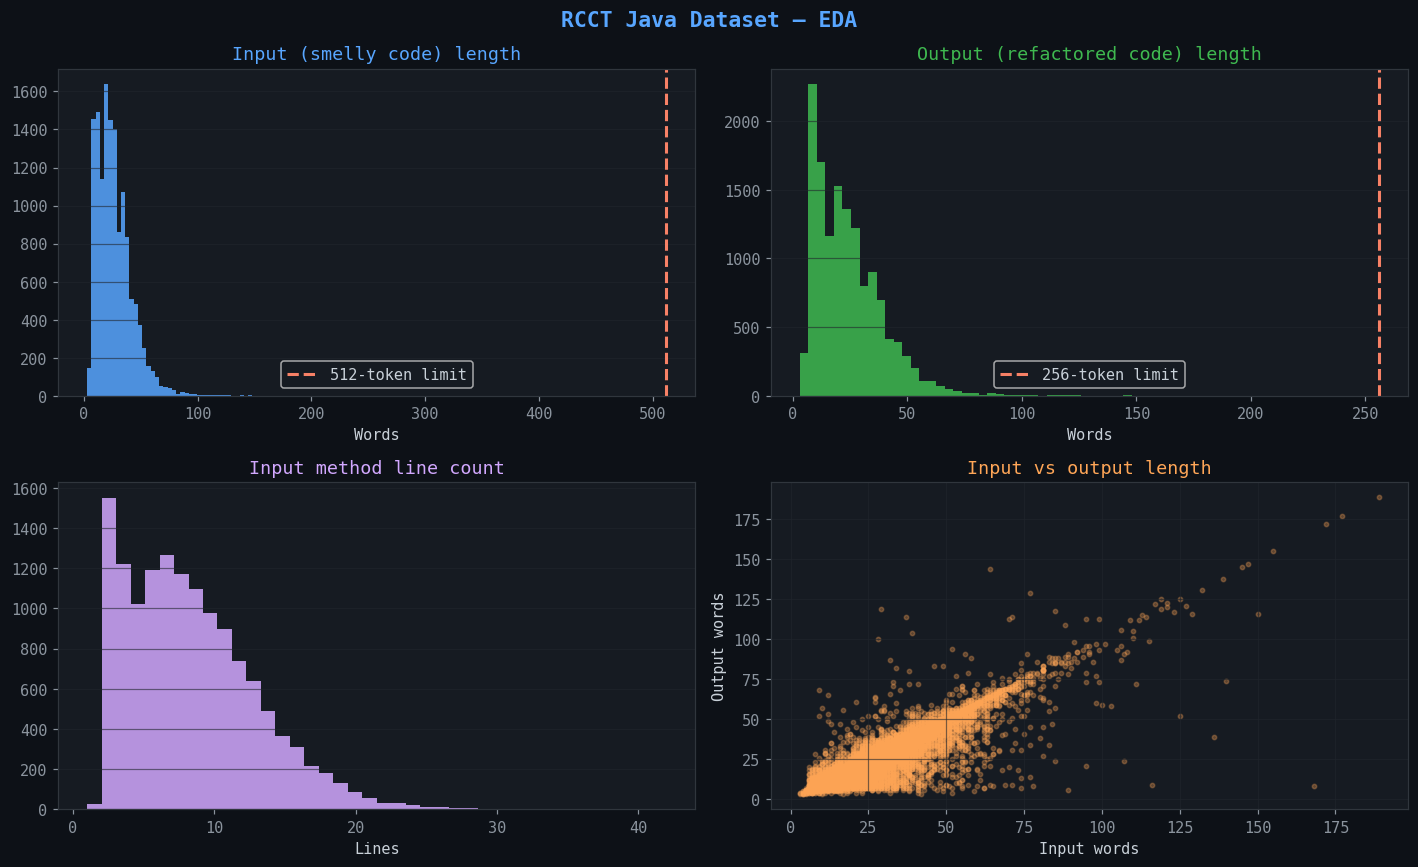

EDA chart saved: /kaggle/working/graphs/eda_dashboard.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("RCCT Java Dataset — EDA", fontsize=14, color="#58a6ff", fontweight="bold")

axes[0,0].hist(train_df["input_words"].clip(0,600), bins=50,
               color=PALETTE[0], alpha=0.85, edgecolor="none")
axes[0,0].axvline(512, color=PALETTE[2], lw=2, ls="--", label="512-token limit")
axes[0,0].set_title("Input (smelly code) length", color=PALETTE[0])
axes[0,0].set_xlabel("Words"); axes[0,0].legend(); axes[0,0].grid(axis="y")

axes[0,1].hist(train_df["output_words"].clip(0,400), bins=50,
               color=PALETTE[1], alpha=0.85, edgecolor="none")
axes[0,1].axvline(256, color=PALETTE[2], lw=2, ls="--", label="256-token limit")
axes[0,1].set_title("Output (refactored code) length", color=PALETTE[1])
axes[0,1].set_xlabel("Words"); axes[0,1].legend(); axes[0,1].grid(axis="y")

axes[1,0].hist(train_df["input_lines"].clip(0,100), bins=40,
               color=PALETTE[3], alpha=0.85, edgecolor="none")
axes[1,0].set_title("Input method line count", color=PALETTE[3])
axes[1,0].set_xlabel("Lines"); axes[1,0].grid(axis="y")

axes[1,1].scatter(train_df["input_words"], train_df["output_words"],
                  alpha=0.3, s=8, c=PALETTE[4])
axes[1,1].set_title("Input vs output length", color=PALETTE[4])
axes[1,1].set_xlabel("Input words"); axes[1,1].set_ylabel("Output words")
axes[1,1].grid(True)

plt.tight_layout()
eda_path = f"{GRAPHS_DIR}/eda_dashboard.png"
plt.savefig(eda_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"EDA chart saved: {eda_path}")

## Step 4 — Quality Filtering + Tokenisation

In [7]:
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
print(f"Vocab size: {tokenizer.vocab_size:,}")

Loading tokenizer: Salesforce/codet5p-770m
Vocab size: 32,100


In [8]:
def quality_filter(item):
    inp = item.get("input", "").strip()
    out = item.get("output", "").strip()
    if len(inp) < 30 or len(out) < 20:                             return False
    if len(inp.split()) > 500:                                     return False
    if len(out.split()) > 250:                                     return False
    if "TODO" in inp or "FIXME" in inp:                            return False
    if not any(k in inp for k in ["public","private","protected"]): return False
    if ";" not in out and "{" not in out:                          return False
    return True

def build_prompt(inp):
    """Must match the prompt format used at inference time in refactor_agent.py."""
    return (f"Refactor the following Java code to improve quality.\n\n"
            f"{inp.strip()}\n\nReturn ONLY the refactored Java code:")

print("Filtering ...")
filtered_train = [r for r in train_data if quality_filter(r)]
filtered_val   = [r for r in val_data   if quality_filter(r)]
filtered_test  = [r for r in test_data  if quality_filter(r)]

for name, orig, filt in [
    ("train", train_data, filtered_train),
    ("val",   val_data,   filtered_val),
    ("test",  test_data,  filtered_test),
]:
    pct = len(filt)/len(orig)*100 if orig else 0
    print(f"  {name:6s}: {len(orig):>6,} -> {len(filt):>6,}  ({pct:.1f}% kept)")

Filtering ...
  train : 13,756 -> 12,872  (93.6% kept)
  val   :  1,719 ->  1,625  (94.5% kept)
  test  :  1,719 ->  1,586  (92.3% kept)


In [9]:
def tokenise_dataset(items, desc=""):
    input_ids_all, attn_all, labels_all = [], [], []
    for item in tqdm(items, desc=desc, ncols=80):
        enc = tokenizer(build_prompt(item["input"]),
                        max_length=MAX_INPUT_LEN, truncation=True)
        lab = tokenizer(text_target=item["output"].strip(),
                        max_length=MAX_TARGET_LEN, truncation=True)
        input_ids_all.append(enc["input_ids"])
        attn_all.append(enc["attention_mask"])
        labels_all.append(lab["input_ids"])
    return Dataset.from_dict({
        "input_ids":      input_ids_all,
        "attention_mask": attn_all,
        "labels":         labels_all,
    })

train_ds = tokenise_dataset(filtered_train, "Tokenising train")
valid_ds = tokenise_dataset(filtered_val,   "Tokenising val  ")
test_ds  = tokenise_dataset(filtered_test,  "Tokenising test ")

print(f"\nFinal sizes  Train:{len(train_ds):,}  Val:{len(valid_ds):,}  Test:{len(test_ds):,}")
print(f"Steps/epoch : {len(train_ds)//(BATCH*GRAD_ACC):,}")
print(f"Total steps : {len(train_ds)//(BATCH*GRAD_ACC)*EPOCHS:,} (max)")

Tokenising train:   0%|                               | 0/12872 [00:00<?, ?it/s]

Tokenising val  :   0%|                                | 0/1625 [00:00<?, ?it/s]

Tokenising test :   0%|                                | 0/1586 [00:00<?, ?it/s]


Final sizes  Train:12,872  Val:1,625  Test:1,586
Steps/epoch : 402
Total steps : 1,206 (max)


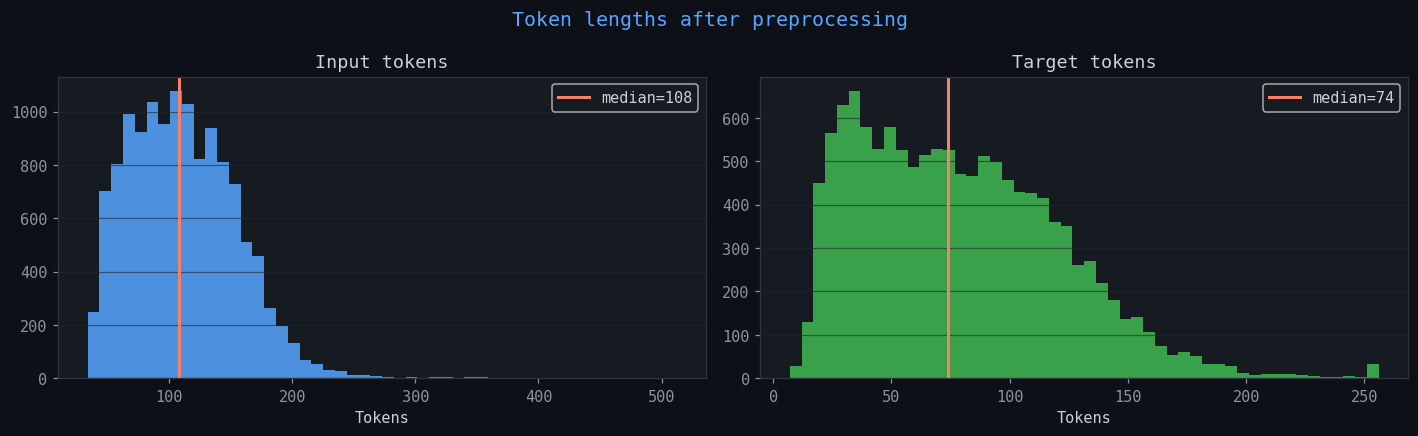

Token length chart saved


In [10]:
# Token length distributions
input_lens  = [len(ids) for ids in train_ds["input_ids"]]
target_lens = [len(ids) for ids in train_ds["labels"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Token lengths after preprocessing", color="#58a6ff", fontsize=13)
axes[0].hist(input_lens, bins=50, color=PALETTE[0], alpha=0.85, edgecolor="none")
axes[0].axvline(int(np.median(input_lens)), color=PALETTE[2], lw=2,
                label=f"median={int(np.median(input_lens))}")
axes[0].set_title("Input tokens"); axes[0].set_xlabel("Tokens")
axes[0].legend(); axes[0].grid(axis="y")
axes[1].hist(target_lens, bins=50, color=PALETTE[1], alpha=0.85, edgecolor="none")
axes[1].axvline(int(np.median(target_lens)), color=PALETTE[2], lw=2,
                label=f"median={int(np.median(target_lens))}")
axes[1].set_title("Target tokens"); axes[1].set_xlabel("Tokens")
axes[1].legend(); axes[1].grid(axis="y")
plt.tight_layout()
plt.savefig(f"{GRAPHS_DIR}/token_lengths.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Token length chart saved")

## Step 5 — Load Model + LoRA

In [11]:
gc.collect()
if DEVICE == "cuda": torch.cuda.empty_cache()

import subprocess
gpu_info = subprocess.run(["nvidia-smi", "--query-gpu=name,compute_cap",
                           "--format=csv,noheader"], capture_output=True, text=True)
print("GPU:", gpu_info.stdout.strip())

print("Loading base model ...")
base_model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,   # fp16 loading — T4 supports it, saves ~3GB VRAM
    device_map="auto",
)

lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=LORA_R, lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROP,
    target_modules=["q","v"], bias="none",
)
model = get_peft_model(base_model, lora_cfg)
model.enable_input_require_grads()

# Cast only trainable LoRA weights to fp32 for stable gradient updates
for param in model.parameters():
    if param.requires_grad:
        param.data = param.data.float()

model.print_trainable_parameters()


GPU: Tesla T4, 7.5
Tesla T4, 7.5
Loading base model ...
trainable params: 4,718,592 || all params: 742,358,016 || trainable%: 0.6356221524251716


## Step 6 — Train

In [12]:
# Load rouge metric — must be defined before compute_metrics
rouge_metric = hf_evaluate.load("rouge")

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    if isinstance(preds, tuple): preds = preds[0]
    preds  = np.clip(preds,  0, tokenizer.vocab_size - 1)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    labels = np.clip(labels, 0, tokenizer.vocab_size - 1)
    decoded_preds  = tokenizer.batch_decode(preds,  skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    decoded_preds  = [p.strip() if p.strip() else "empty" for p in decoded_preds]
    decoded_labels = [l.strip() if l.strip() else "empty" for l in decoded_labels]
    result = rouge_metric.compute(
        predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    return {k: round(v, 4) for k, v in result.items()}

TRAINING_LOG = []

class MetricsCallback(EarlyStoppingCallback):
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            TRAINING_LOG.append({
                "epoch":     state.epoch,
                "eval_loss": metrics.get("eval_loss"),
                "rougeL":    metrics.get("eval_rougeL"),
                "rouge1":    metrics.get("eval_rouge1"),
                "rouge2":    metrics.get("eval_rouge2"),
            })
        super().on_evaluate(args, state, control, metrics=metrics, **kwargs)

collator = DataCollatorForSeq2Seq(
    tokenizer, model=model, label_pad_token_id=-100, pad_to_multiple_of=8)

# Subsample validation to 300 examples — speeds up each val pass 5x
val_ds_fast = valid_ds.select(range(min(300, len(valid_ds))))
print(f"Val subset for training: {len(val_ds_fast)} examples (full val={len(valid_ds)})")

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH,
    per_device_eval_batch_size=8,        # larger eval batch — generation uses less VRAM
    gradient_accumulation_steps=GRAD_ACC,
    learning_rate=LR,
    warmup_steps=200,
    weight_decay=0.01,
    fp16=True,                           # T4 compute 7.5 — fp16 fully supported
    bf16=False,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,
    generation_num_beams=1,              # greedy decoding during eval — much faster
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    save_total_limit=2,
    logging_dir=LOG_DIR,
    logging_steps=50,
    report_to="none",
    seed=42,
    dataloader_num_workers=2,
)

trainer = Seq2SeqTrainer(
    model=model, args=training_args,
    train_dataset=train_ds, eval_dataset=val_ds_fast,
    tokenizer=tokenizer, data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[MetricsCallback(early_stopping_patience=2)],
)

print("Starting training ...")
print(f"  Train:{len(train_ds):,} | Val:{len(val_ds_fast):,} | Epochs:{EPOCHS}")
print(f"  EffBatch:{BATCH*GRAD_ACC} | Steps/epoch:{len(train_ds)//(BATCH*GRAD_ACC):,}")
train_result = trainer.train()

# Auto-save immediately
print("\nAuto-saving ...")
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
shutil.make_archive("/kaggle/working/refactor_agent_final","zip",
                    "/kaggle/working","refactor_agent_final")
print(f"Saved: {os.path.getsize("/kaggle/working/refactor_agent_final.zip")/1e6:.1f} MB")
print(f"Runtime: {train_result.metrics['train_runtime']/60:.1f} min")


Val subset for training: 300 examples (full val=1625)
Starting training ...
  Train:12,872 | Val:300 | Epochs:3
  EffBatch:32 | Steps/epoch:402


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
0,0.133500,0.114848,0.881100,0.813700,0.869300,0.879300
1,0.118900,0.109744,0.888400,0.824900,0.877100,0.887200
2,0.111700,0.108713,0.871500,0.804400,0.859300,0.870500



Auto-saving ...
Saved: 123.0 MB
Runtime: 136.2 min


## Step 7 — Comprehensive Evaluation

**8 metrics covering different aspects:**

| Metric | What it measures |
|--------|------------------|
| ROUGE-1/2/L | N-gram overlap with reference |
| BLEU-4 | 4-gram precision |
| CodeBLEU | Code-specific: syntax tree + dataflow match |
| Exact Match | % predictions identical to reference |
| AST Validity | % outputs that parse as valid Java |
| Method Extraction Rate | % outputs with new private helper methods |
| LOC Delta | Average line count change |
| Normalised Edit Distance | Token-level similarity |

In [13]:
# Generate predictions on test set
N = min(200, len(test_ds))
test_subset  = test_ds.select(range(N))
raw_inputs   = [filtered_test[i]["input"]  for i in range(N)]
raw_refs     = [filtered_test[i]["output"] for i in range(N)]

model.eval()
pred_ids_list, label_ids_list = [], []

print(f"Generating predictions on {N} test examples ...")
for i in tqdm(range(0, N, 8), ncols=80):
    batch = test_subset.select(range(i, min(i+8, N)))
    inp_tensors  = [torch.tensor(x) for x in batch["input_ids"]]
    attn_tensors = [torch.tensor(x) for x in batch["attention_mask"]]
    inp_padded  = torch.nn.utils.rnn.pad_sequence(
        inp_tensors, batch_first=True,
        padding_value=tokenizer.pad_token_id).to(model.device)
    attn_padded = torch.nn.utils.rnn.pad_sequence(
        attn_tensors, batch_first=True, padding_value=0).to(model.device)
    with torch.no_grad():
        out = model.generate(
            input_ids=inp_padded, attention_mask=attn_padded,
            max_new_tokens=MAX_TARGET_LEN, num_beams=2)
    pred_ids_list.extend(out.cpu().numpy().tolist())
    label_ids_list.extend(batch["labels"])

pred_ids_list  = [np.clip(p, 0, tokenizer.vocab_size-1) for p in pred_ids_list]
label_ids_list = [np.where(np.array(l)!=-100, np.array(l), tokenizer.pad_token_id)
                  for l in label_ids_list]
label_ids_list = [np.clip(l, 0, tokenizer.vocab_size-1) for l in label_ids_list]

predictions = tokenizer.batch_decode(pred_ids_list,  skip_special_tokens=True)
references  = tokenizer.batch_decode(label_ids_list, skip_special_tokens=True)
predictions = [p.strip() if p.strip() else "empty" for p in predictions]
references  = [r.strip() if r.strip() else "empty" for r in references]
print(f"Generated {len(predictions)} predictions")

Generating predictions on 200 test examples ...


  0%|                                                    | 0/25 [00:00<?, ?it/s]

Generated 200 predictions


In [14]:
# ── Metric 1+2+3: ROUGE + BLEU ───────────────────────────────────────────
rouge_result = rouge_metric.compute(
    predictions=predictions, references=references, use_stemmer=True)
r1 = round(rouge_result["rouge1"], 4)
r2 = round(rouge_result["rouge2"], 4)
rL = round(rouge_result["rougeL"], 4)

sacrebleu  = hf_evaluate.load("sacrebleu")
bleu_score = sacrebleu.compute(
    predictions=predictions,
    references=[[r] for r in references])["score"]

# ── Metric 4: CodeBLEU ───────────────────────────────────────────────────
codebleu_score = None
if HAS_CODEBLEU:
    try:
        cb = calc_codebleu(
            references=[[r] for r in references],
            predictions=predictions,
            lang="java", weights=(0.25,0.25,0.25,0.25))
        codebleu_score = round(cb["codebleu"], 4)
        print(f"CodeBLEU components: {cb}")
    except Exception as e:
        print(f"CodeBLEU failed: {e}")

# ── Metric 5: Exact Match ────────────────────────────────────────────────
def normalise_code(code):
    """Remove whitespace differences for fair comparison."""
    return " ".join(code.split())

exact_matches = sum(
    normalise_code(p) == normalise_code(r)
    for p, r in zip(predictions, references)
)
exact_match_rate = round(exact_matches / len(predictions), 4)

# ── Metric 6: AST Validity ───────────────────────────────────────────────
def is_valid_java(code):
    if HAS_JAVALANG:
        try:
            test = code if "class " in code else f"public class T {{\n{code}\n}}"
            javalang.parse.parse(test)
            return True
        except:
            return False
    else:
        return code.count("{") == code.count("}") and ";" in code

validity = [is_valid_java(p) for p in predictions]
ast_validity_rate = round(sum(validity) / len(validity), 4)
syntax_error_rate = round(1 - ast_validity_rate, 4)

# ── Metric 7: Method Extraction Rate ─────────────────────────────────────
def has_extracted_method(code):
    """Check if model added private helper methods."""
    return bool(re.search(r"\bprivate\s+\w+\s+\w+\s*\(", code))

extracted = [has_extracted_method(p) for p in predictions]
extraction_rate = round(sum(extracted) / len(extracted), 4)

# ── Metric 8: LOC Delta ──────────────────────────────────────────────────
pred_locs = [len([l for l in p.split("\n") if l.strip()]) for p in predictions]
ref_locs  = [len([l for l in r.split("\n") if r.strip()]) for r in references]
raw_locs  = [len([l for l in inp.split("\n") if l.strip()]) for inp in raw_inputs]

avg_loc_delta_vs_input = round(np.mean([r-p for r,p in zip(raw_locs, pred_locs)]), 2)
avg_loc_delta_vs_ref   = round(np.mean([r-p for r,p in zip(ref_locs, pred_locs)]), 2)

# ── Metric 9: Normalised Edit Distance ───────────────────────────────────
def normalised_edit_distance(s1, s2):
    """Token-level Levenshtein distance, normalised 0-1 (0=identical)."""
    t1 = s1.split()
    t2 = s2.split()
    m, n = len(t1), len(t2)
    if m == 0 and n == 0: return 0.0
    dp = list(range(n+1))
    for i in range(1, m+1):
        prev = dp[:]
        dp[0] = i
        for j in range(1, n+1):
            dp[j] = prev[j-1] if t1[i-1]==t2[j-1] else 1 + min(prev[j], dp[j-1], prev[j-1])
    return round(dp[n] / max(m, n), 4)

edit_dists = [normalised_edit_distance(p, r) for p, r in zip(predictions, references)]
avg_edit_dist = round(np.mean(edit_dists), 4)
similarity_score = round(1 - avg_edit_dist, 4)  # higher = more similar

# ── Print summary ─────────────────────────────────────────────────────────
print("=" * 55)
print("COMPREHENSIVE EVALUATION — Test Set")
print("=" * 55)
print(f"  ROUGE-1              : {r1:.4f}")
print(f"  ROUGE-2              : {r2:.4f}")
print(f"  ROUGE-L              : {rL:.4f}")
print(f"  BLEU-4               : {bleu_score:.2f}")
if codebleu_score:
    print(f"  CodeBLEU             : {codebleu_score:.4f}")
print(f"  Exact Match          : {exact_match_rate:.4f}  ({exact_matches}/{len(predictions)})")
print(f"  AST Validity         : {ast_validity_rate:.4f}  ({sum(validity)}/{len(validity)} valid)")
print(f"  Syntax Error Rate    : {syntax_error_rate:.4f}")
print(f"  Method Extraction    : {extraction_rate:.4f}  ({sum(extracted)}/{len(extracted)} applied)")
print(f"  LOC delta (vs input) : {avg_loc_delta_vs_input:+.1f} lines avg")
print(f"  Token Similarity     : {similarity_score:.4f}  (1=identical)")
print(f"  Edit Distance        : {avg_edit_dist:.4f}  (0=identical)")

CodeBLEU failed: Tree-sitter language for java not available. Please install the language parser using `pip install tree-sitter-java`.
COMPREHENSIVE EVALUATION — Test Set
  ROUGE-1              : 0.8766
  ROUGE-2              : 0.8156
  ROUGE-L              : 0.8614
  BLEU-4               : 82.01
  Exact Match          : 0.0950  (19/200)
  AST Validity         : 0.9900  (198/200 valid)
  Syntax Error Rate    : 0.0100
  Method Extraction    : 0.0900  (18/200 applied)
  LOC delta (vs input) : +0.3 lines avg
  Token Similarity     : 0.7849  (1=identical)
  Edit Distance        : 0.2151  (0=identical)


In [15]:
# Qualitative examples
print("\nQualitative examples (first 5)")
for i in range(min(5, len(predictions))):
    print(f"\n[{i+1}] INPUT     : {raw_inputs[i][:120]} ...")
    print(f"    REFERENCE : {references[i][:150]}")
    print(f"    GENERATED : {predictions[i][:150]}")
    print(f"    AST Valid : {validity[i]}  |  Extracted: {extracted[i]}")


Qualitative examples (first 5)

[1] INPUT     : private static Set<String> getRootQualifiers(ResourceTypes resourceTypes) {
    return resourceTypes.getRoots().stream() ...
    REFERENCE : private static Set<String> getRootQualifiers(ResourceTypes resourceTypes) {
    return resourceTypes.getRoots().stream()
     .map(ResourceType::getQu
    GENERATED : private static Set<String> getRootQualifiers(ResourceTypes resourceTypes) {
    return resourceTypes.getRoots().stream()
     .map(ResourceType::getQu
    AST Valid : True  |  Extracted: False

[2] INPUT     : public RuntimeFilterManager(QueryWorkUnit workUnit, DrillbitContext drillbitContext) {
    this.rootWrapper = workUnit.g ...
    REFERENCE : public RuntimeFilterManager(QueryWorkUnit workUnit, DrillbitContext drillbitContext) {
    this.rootWrapper = workUnit.getRootWrapper();
    this.dril
    GENERATED : public RuntimeFilterManager(QueryWorkUnit workUnit, DrillbitContext drillbitContext) {
    this.rootWrapper = workUnit.getRoo

## Step 8 — Visualisations (all saved to /kaggle/working/graphs/)

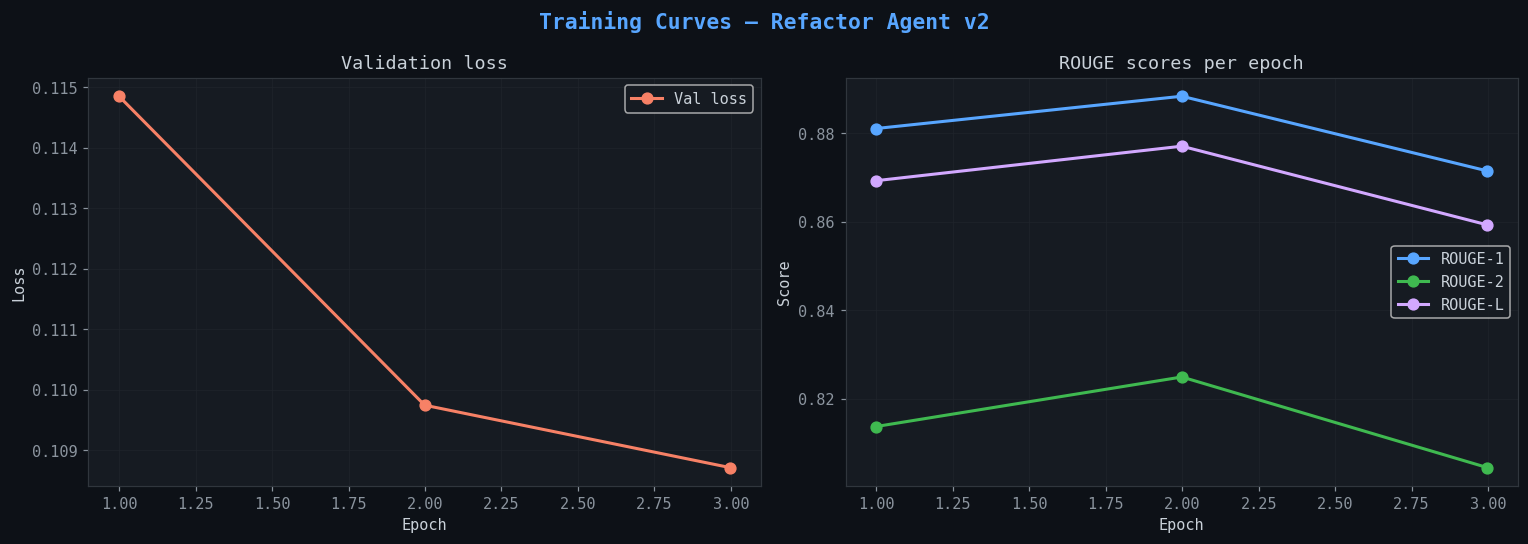

training_curves.png saved


In [16]:
# 1. Training curves
log_df = pd.DataFrame(TRAINING_LOG)
if len(log_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training Curves — Refactor Agent v2",
                 color="#58a6ff", fontsize=14, fontweight="bold")
    axes[0].plot(log_df["epoch"], log_df["eval_loss"],
                 "o-", color=PALETTE[2], lw=2, ms=7, label="Val loss")
    axes[0].set_title("Validation loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].grid(True); axes[0].legend()
    for col, label, color in [
        ("rouge1","ROUGE-1",PALETTE[0]),
        ("rouge2","ROUGE-2",PALETTE[1]),
        ("rougeL","ROUGE-L",PALETTE[3]),
    ]:
        if col in log_df.columns:
            axes[1].plot(log_df["epoch"], log_df[col],
                         "o-", color=color, lw=2, ms=7, label=label)
    axes[1].set_title("ROUGE scores per epoch")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
    axes[1].grid(True); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"{GRAPHS_DIR}/training_curves.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("training_curves.png saved")
else:
    print("No training log")

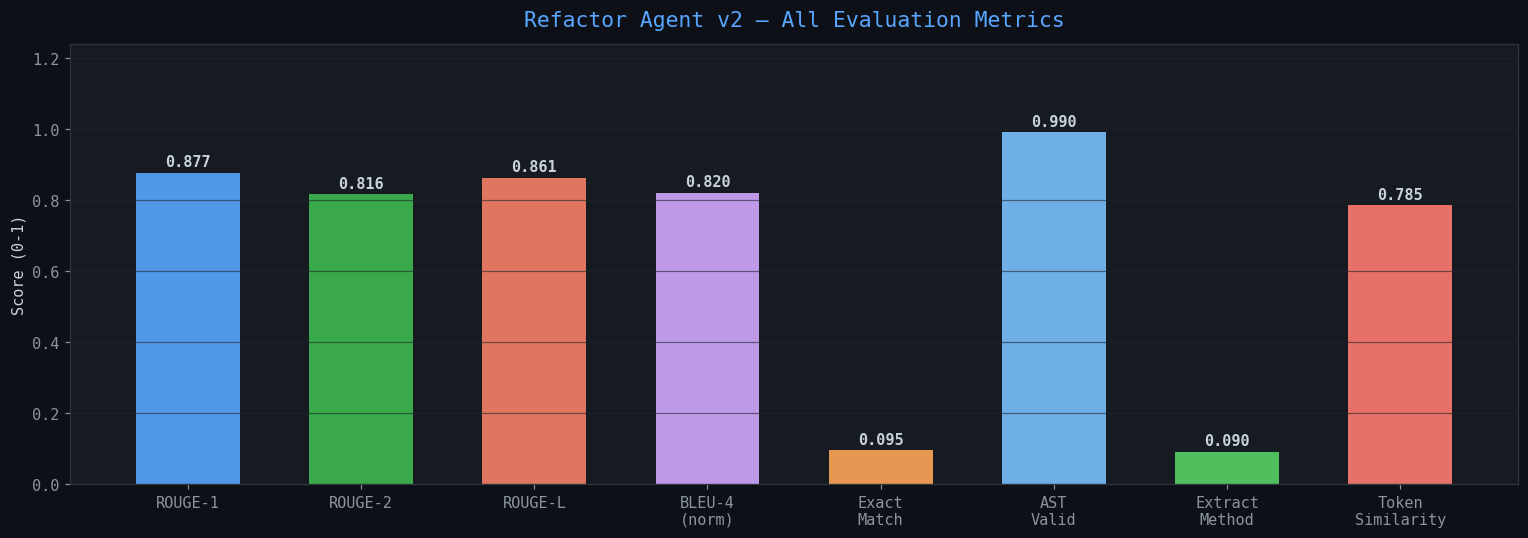

metrics_all.png saved


In [17]:
# 2. Metrics bar chart
metric_names = ["ROUGE-1","ROUGE-2","ROUGE-L","BLEU-4\n(norm)","Exact\nMatch","AST\nValid","Extract\nMethod","Token\nSimilarity"]
metric_vals  = [r1, r2, rL, bleu_score/100, exact_match_rate,
                ast_validity_rate, extraction_rate, similarity_score]
bar_colors   = PALETTE[:len(metric_names)]

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor("#0d1117"); ax.set_facecolor("#161b22")
bars = ax.bar(metric_names, metric_vals, color=bar_colors, width=0.6, alpha=0.9)
for b, v in zip(bars, metric_vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.3f}",
            ha="center", va="bottom", color="#c9d1d9", fontsize=10, fontweight="bold")
ax.set_ylim(0, max(metric_vals)*1.25)
ax.set_title("Refactor Agent v2 — All Evaluation Metrics",
             color="#58a6ff", fontsize=14, pad=12)
ax.set_ylabel("Score (0-1)"); ax.grid(axis="y", color="#21262d", alpha=0.6)
for spine in ax.spines.values(): spine.set_edgecolor("#30363d")
plt.tight_layout()
plt.savefig(f"{GRAPHS_DIR}/metrics_all.png", dpi=130, bbox_inches="tight")
plt.show()
print("metrics_all.png saved")

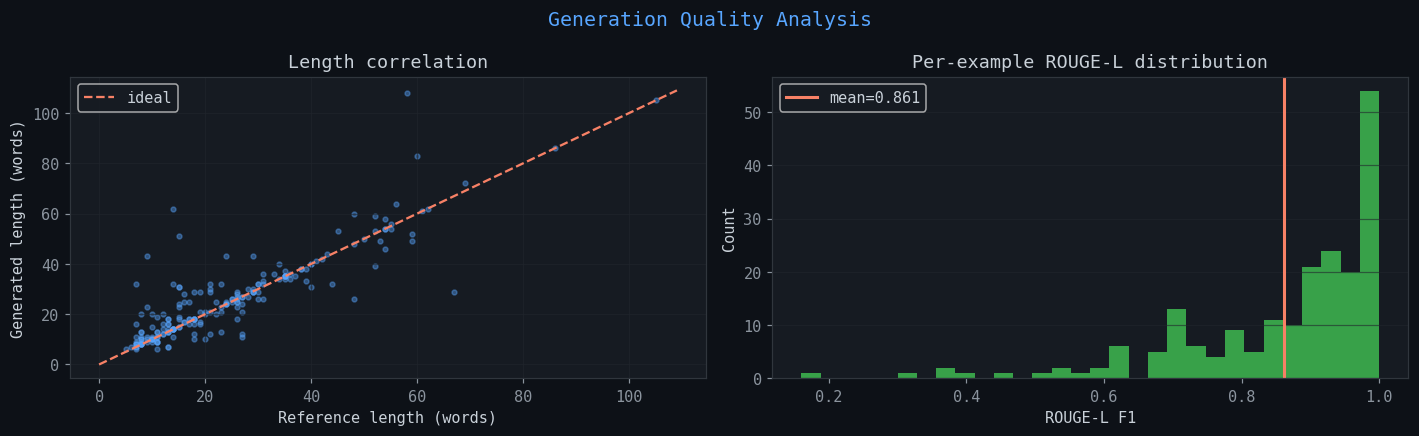

generation_quality.png saved


In [18]:
# 3. Per-example ROUGE-L distribution
from rouge_score import rouge_scorer as rs_lib
scorer = rs_lib.RougeScorer(["rougeL"], use_stemmer=True)
per_rougel = [scorer.score(r,p)["rougeL"].fmeasure
              for r,p in zip(references, predictions)]

pred_lens = [len(p.split()) for p in predictions]
ref_lens  = [len(r.split()) for r in references]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Generation Quality Analysis", color="#58a6ff", fontsize=13)
axes[0].scatter(ref_lens, pred_lens, alpha=0.4, s=10, c=PALETTE[0])
max_l = max(max(ref_lens)+1, max(pred_lens)+1)
axes[0].plot([0,max_l],[0,max_l], color=PALETTE[2], lw=1.5, ls="--", label="ideal")
axes[0].set_xlabel("Reference length (words)")
axes[0].set_ylabel("Generated length (words)")
axes[0].set_title("Length correlation"); axes[0].legend(); axes[0].grid(True)
axes[1].hist(per_rougel, bins=30, color=PALETTE[1], alpha=0.85, edgecolor="none")
axes[1].axvline(np.mean(per_rougel), color=PALETTE[2], lw=2,
                label=f"mean={np.mean(per_rougel):.3f}")
axes[1].set_title("Per-example ROUGE-L distribution")
axes[1].set_xlabel("ROUGE-L F1"); axes[1].set_ylabel("Count")
axes[1].legend(); axes[1].grid(axis="y")
plt.tight_layout()
plt.savefig(f"{GRAPHS_DIR}/generation_quality.png", dpi=130, bbox_inches="tight")
plt.show()
print("generation_quality.png saved")

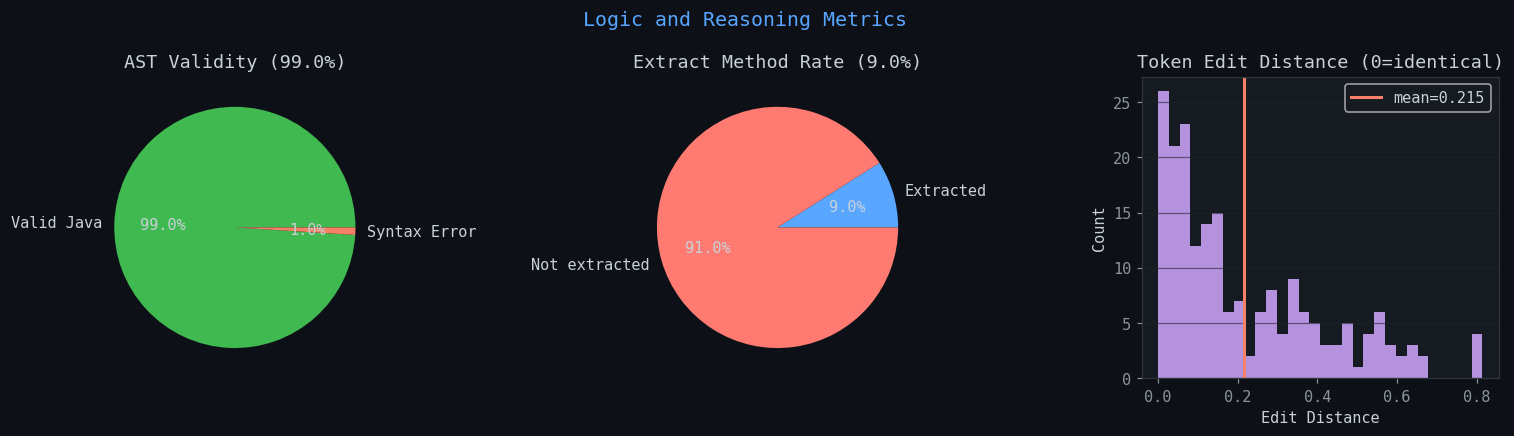

logic_reasoning.png saved


In [19]:
# 4. Logic & reasoning metrics chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Logic and Reasoning Metrics", color="#58a6ff", fontsize=13)

# AST validity pie
axes[0].pie([sum(validity), len(validity)-sum(validity)],
            labels=["Valid Java", "Syntax Error"],
            colors=[PALETTE[1], PALETTE[2]], autopct="%1.1f%%",
            textprops={"color":"#c9d1d9"})
axes[0].set_title(f"AST Validity ({ast_validity_rate:.1%})")

# Method extraction pie
axes[1].pie([sum(extracted), len(extracted)-sum(extracted)],
            labels=["Extracted", "Not extracted"],
            colors=[PALETTE[0], PALETTE[7]], autopct="%1.1f%%",
            textprops={"color":"#c9d1d9"})
axes[1].set_title(f"Extract Method Rate ({extraction_rate:.1%})")

# Edit distance distribution
axes[2].hist(edit_dists, bins=30, color=PALETTE[3], alpha=0.85, edgecolor="none")
axes[2].axvline(avg_edit_dist, color=PALETTE[2], lw=2,
                label=f"mean={avg_edit_dist:.3f}")
axes[2].set_title("Token Edit Distance (0=identical)")
axes[2].set_xlabel("Edit Distance"); axes[2].set_ylabel("Count")
axes[2].legend(); axes[2].grid(axis="y")

plt.tight_layout()
plt.savefig(f"{GRAPHS_DIR}/logic_reasoning.png", dpi=130, bbox_inches="tight")
plt.show()
print("logic_reasoning.png saved")

## Step 9 — Save All Results + Zip

In [20]:
# Save complete evaluation results JSON
eval_results = {
    "timestamp":  datetime.now().isoformat(),
    "version":    "v2",
    "base_model": MODEL_NAME,
    "dataset":    "RCCT Java",
    "n_test":     N,
    "token_limits": {
        "input":  MAX_INPUT_LEN,
        "output": MAX_TARGET_LEN,
        "note":   "Fixed by CodeT5+ architecture. codet5p-2b offers 2048 tokens."
    },
    "hyperparameters": {
        "lr": LR, "lora_r": LORA_R, "lora_alpha": LORA_ALPHA,
        "lora_dropout": LORA_DROP,
        "batch_size": BATCH, "grad_accum": GRAD_ACC,
        "eff_batch": BATCH*GRAD_ACC, "epochs": EPOCHS,
    },
    "metrics": {
        "rouge1":              r1,
        "rouge2":              r2,
        "rougeL":              rL,
        "bleu4":               round(bleu_score, 2),
        "codebleu":            codebleu_score,
        "exact_match":         exact_match_rate,
        "ast_validity":        ast_validity_rate,
        "syntax_error_rate":   syntax_error_rate,
        "method_extraction":   extraction_rate,
        "avg_loc_delta":       avg_loc_delta_vs_input,
        "token_similarity":    similarity_score,
        "avg_edit_distance":   avg_edit_dist,
    },
    "training_log": TRAINING_LOG,
    "v1_bugs_fixed": [
        "Seq2SeqTrainer (was plain Trainer)",
        "Input=512/Target=256 (was both 256)",
        "Dynamic padding (was max_length padding)",
        "fp16=True (was False)",
        "load_best_model_at_end=True",
        "Fresh training (no Colab->Kaggle transfer)",
    ],
}

results_path = f"{RESULTS_DIR}/evaluation_results.json"
with open(results_path, "w", encoding="utf-8") as f:
    json.dump(eval_results, f, indent=2)
print(f"Results saved: {results_path}")

# Save human-readable text report
report_lines = [
    "=" * 60,
    "REFACTOR AGENT v2 — EVALUATION REPORT",
    f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}",
    "=" * 60,
    "",
    "DATASET",
    f"  Train : {len(train_ds):,}  Val : {len(valid_ds):,}  Test : {len(test_ds):,}",
    f"  Input window  : {MAX_INPUT_LEN} tokens (CodeT5+ fixed limit)",
    f"  Output window : {MAX_TARGET_LEN} tokens",
    "",
    "HYPERPARAMETERS",
    f"  LR={LR:.0e}  LoRA r={LORA_R}  alpha={LORA_ALPHA}  dropout={LORA_DROP}",
    f"  Batch={BATCH}  GradAcc={GRAD_ACC}  EffBatch={BATCH*GRAD_ACC}  Epochs={EPOCHS}",
    "",
    "EVALUATION METRICS (test set)",
    "-" * 40,
    f"  ROUGE-1           : {r1:.4f}",
    f"  ROUGE-2           : {r2:.4f}",
    f"  ROUGE-L           : {rL:.4f}",
    f"  BLEU-4            : {bleu_score:.2f}",
]
if codebleu_score:
    report_lines.append(f"  CodeBLEU          : {codebleu_score:.4f}")
report_lines += [
    f"  Exact Match       : {exact_match_rate:.4f}  ({exact_matches}/{N})",
    f"  AST Validity      : {ast_validity_rate:.4f}  ({sum(validity)}/{N} valid)",
    f"  Syntax Error Rate : {syntax_error_rate:.4f}",
    f"  Method Extraction : {extraction_rate:.4f}  ({sum(extracted)}/{N})",
    f"  LOC Delta (input) : {avg_loc_delta_vs_input:+.1f} lines avg",
    f"  Token Similarity  : {similarity_score:.4f}",
    f"  Edit Distance     : {avg_edit_dist:.4f}  (0=identical)",
    "",
    "SAVED FILES",
    f"  {GRAPHS_DIR}/training_curves.png",
    f"  {GRAPHS_DIR}/metrics_all.png",
    f"  {GRAPHS_DIR}/generation_quality.png",
    f"  {GRAPHS_DIR}/logic_reasoning.png",
    f"  {GRAPHS_DIR}/eda_dashboard.png",
    f"  {GRAPHS_DIR}/token_lengths.png",
    f"  {RESULTS_DIR}/evaluation_results.json",
    "=" * 60,
]
report_text = "\n".join(report_lines)
print(report_text)

report_path = f"{RESULTS_DIR}/evaluation_report.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)
print(f"\nReport saved: {report_path}")

Results saved: /kaggle/working/results/evaluation_results.json
REFACTOR AGENT v2 — EVALUATION REPORT
Generated: 2026-03-21 13:08

DATASET
  Train : 12,872  Val : 1,625  Test : 1,586
  Input window  : 512 tokens (CodeT5+ fixed limit)
  Output window : 256 tokens

HYPERPARAMETERS
  LR=2e-04  LoRA r=16  alpha=32  dropout=0.05
  Batch=2  GradAcc=16  EffBatch=32  Epochs=3

EVALUATION METRICS (test set)
----------------------------------------
  ROUGE-1           : 0.8766
  ROUGE-2           : 0.8156
  ROUGE-L           : 0.8614
  BLEU-4            : 82.01
  Exact Match       : 0.0950  (19/200)
  AST Validity      : 0.9900  (198/200 valid)
  Syntax Error Rate : 0.0100
  Method Extraction : 0.0900  (18/200)
  LOC Delta (input) : +0.3 lines avg
  Token Similarity  : 0.7849
  Edit Distance     : 0.2151  (0=identical)

SAVED FILES
  /kaggle/working/graphs/training_curves.png
  /kaggle/working/graphs/metrics_all.png
  /kaggle/working/graphs/generation_quality.png
  /kaggle/working/graphs/logic_re

In [21]:
# Copy all graphs and results into the model folder for one-zip download
for src_dir in [GRAPHS_DIR, RESULTS_DIR]:
    dst_dir = os.path.join(OUTPUT_DIR, os.path.basename(src_dir))
    if os.path.exists(src_dir):
        shutil.copytree(src_dir, dst_dir, dirs_exist_ok=True)

# Final zip
shutil.make_archive("/kaggle/working/refactor_agent_final", "zip",
                    "/kaggle/working", "refactor_agent_final")
zip_mb = os.path.getsize("/kaggle/working/refactor_agent_final.zip")/1e6
print(f"Final zip: {zip_mb:.1f} MB")
print("Download: Kaggle Output tab -> refactor_agent_final.zip")

print("\n" + "="*55)
print("ALL DONE")
print("="*55)
print(f"  ROUGE-L    : {rL:.4f}")
print(f"  BLEU-4     : {bleu_score:.2f}")
if codebleu_score: print(f"  CodeBLEU   : {codebleu_score:.4f}")
print(f"  AST Valid  : {ast_validity_rate:.1%}")
print(f"  Extracted  : {extraction_rate:.1%}")
print(f"  Similarity : {similarity_score:.4f}")

Final zip: 123.4 MB
Download: Kaggle Output tab -> refactor_agent_final.zip

ALL DONE
  ROUGE-L    : 0.8614
  BLEU-4     : 82.01
  AST Valid  : 99.0%
  Extracted  : 9.0%
  Similarity : 0.7849
